<div align="center">

# Machine Learning
## Regresión Logistica
### Solución Parcial
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 17 de Abril del 2026

<br><br><br><br><br><br><br><br><br><br>

---

## **Resumen**
<p style="text-align: justify">
Este documento presenta el desarrollo completo de un modelo de <b>Machine Learning</b> basado en <b>Regresión Logística Multinomial</b>, aplicado al dataset <i>Obesity Levels</i>, cuyo objetivo es clasificar el nivel de obesidad de una persona en una de siete categorías posibles. Para ello, se realizó un proceso estructurado que incluyó la exploración inicial del dataset, verificación de valores nulos y duplicados, y la preparación de variables numéricas y categóricas. Posteriormente, se aplicaron técnicas de preprocesamiento como <b>OneHotEncoding</b> para la codificación de variables categóricas y <b>StandardScaler</b> para el escalado de variables numéricas, con el fin de garantizar un entrenamiento estable del modelo.
</p>

<p style="text-align: justify">
Además, se evaluó la distribución de clases para identificar un posible desbalance en la variable objetivo, determinando que la base se encontraba relativamente balanceada y por lo tanto no fue necesario aplicar técnicas de oversampling como SMOTE. También se realizó un análisis de correlación para detectar posibles variables altamente correlacionadas, con el propósito de reducir redundancia y mejorar la interpretabilidad del modelo. Finalmente, se entrenó el modelo comparando distintos solvers de optimización y diferentes valores del parámetro de regularización <b>C</b>, seleccionando la combinación más adecuada según su rendimiento.
</p>

<p style="text-align: justify">
Como resultado, el modelo final alcanzó un desempeño destacado con un <b>accuracy aproximado del 94.42%</b>, acompañado de una matriz de confusión y métricas de clasificación (precision, recall y f1-score) que permitieron identificar las clases con mejor predicción y aquellas con mayor confusión, especialmente en niveles intermedios de sobrepeso. En conclusión, este trabajo evidencia la utilidad de la regresión logística multinomial como método eficiente y confiable para problemas de clasificación multiclase, resaltando además la importancia del preprocesamiento y la selección adecuada de hiperparámetros para maximizar el rendimiento del modelo.
</p>

</div>

# Sección 1 — Selección del Dataset

In [122]:
import pandas as pd
df = pd.read_csv("../Bases/ObesityDataSet_raw_and_data_sinthetic.csv")

**Dataset:** Obesity Levels

**Fuente:** Kaggle (Obesity Levels Dataset)

**Clases:** 7 niveles de obesidad (NObeyesdad)

**Registros:** ~2111

**Justificación:**
<p>Este dataset es apropiado para aplicar Regresión Logística Multinomial porque la variable objetivo contiene múltiples clases (7 categorías distintas de nivel de obesidad), por lo cual se requiere un modelo de clasificación multiclase. Además, el dataset contiene variables numéricas y categóricas que pueden ser transformadas y utilizadas como predictores, permitiendo aplicar un flujo completo de preprocesamiento, balanceo, selección de features y comparación de solvers.

# SECCIÓN 2 — Limpieza y Preprocesamiento

In [123]:
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Tipo de datos

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

### Nullos

In [125]:
print(df.isnull().sum())

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


### Duplicados

In [126]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 24


## 2.2 Tratamiento requerido

In [127]:
df = df.drop_duplicates()
print("Duplicados después:", df.duplicated().sum())

Duplicados después: 0


### Separar x de Y

In [128]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

### Codificación categórica + escalado numérico:

In [129]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# SECCIÓN 3 — Desbalance de Clases

## 3.1 Visualizar distribución

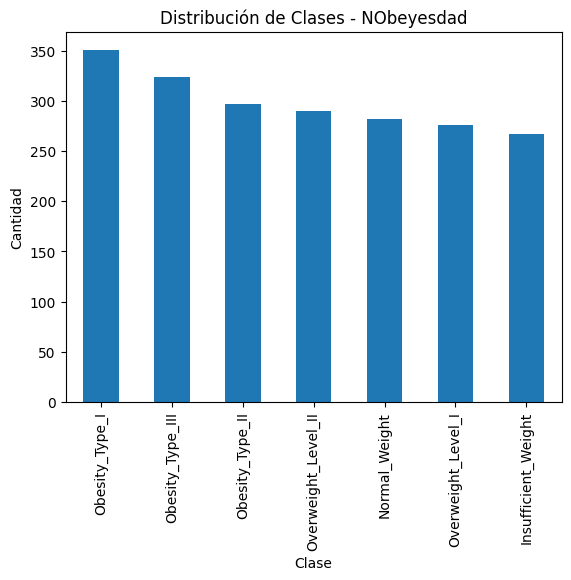

In [130]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Distribución de Clases - NObeyesdad")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

### Análisis del Desbalance de Clases

Al observar la distribución de la variable objetivo **NObeyesdad**, se evidencia que las clases presentan una cantidad de registros relativamente similar. 
Las frecuencias oscilan aproximadamente entre 270 y 350 registros por clase, lo cual indica que el dataset se encuentra **moderadamente balanceado**.

Aunque existen diferencias leves entre clases (por ejemplo, "Obesity_Type_I" presenta una mayor frecuencia), no se observa un desbalance severo que pueda afectar 
de manera crítica el desempeño del modelo.

Por lo tanto, no se aplicará ninguna técnica de balanceo como SMOTE, ya que el dataset conserva una distribución adecuada y el uso de balanceo artificial podría 
introducir ruido o sobreajuste en el entrenamiento.

## 3.2 Balanceo

## ratio= (clase mayor) / (clase menor)

**Regla Si ....**

- ratio < 1.5 → bastante balanceado (no aplicar SMOTE)
- 1.5 ≤ ratio < 2 → leve desbalance (opcional)
- ratio ≥ 2 → desbalance claro (recomendado balancear)
- ratio ≥ 3 → desbalance severo (casi obligatorio balancear)

In [131]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Preprocesar SIEMPRE
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Recalcular ratio con y_train (recomendado)
conteo_train = y_train.value_counts()
ratio_train = conteo_train.max() / conteo_train.min()

print(f"Ratio train: {ratio_train:.2f}")

# Aplicar SMOTE solo si es necesario
if ratio_train >= 2:
    print("Aplicando SMOTE...")

    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_train_prep, y_train)

    print("Antes:\n", y_train.value_counts())
    print("Después:\n", pd.Series(y_train_final).value_counts())
else:
    print("No se aplica SMOTE.")
    X_train_final, y_train_final = X_train_prep, y_train

# Variable final de test (SIEMPRE igual)
X_test_final = X_test_prep

Ratio train: 1.31
No se aplica SMOTE.


# SECCIÓN 4 — Correlación y selección de Features

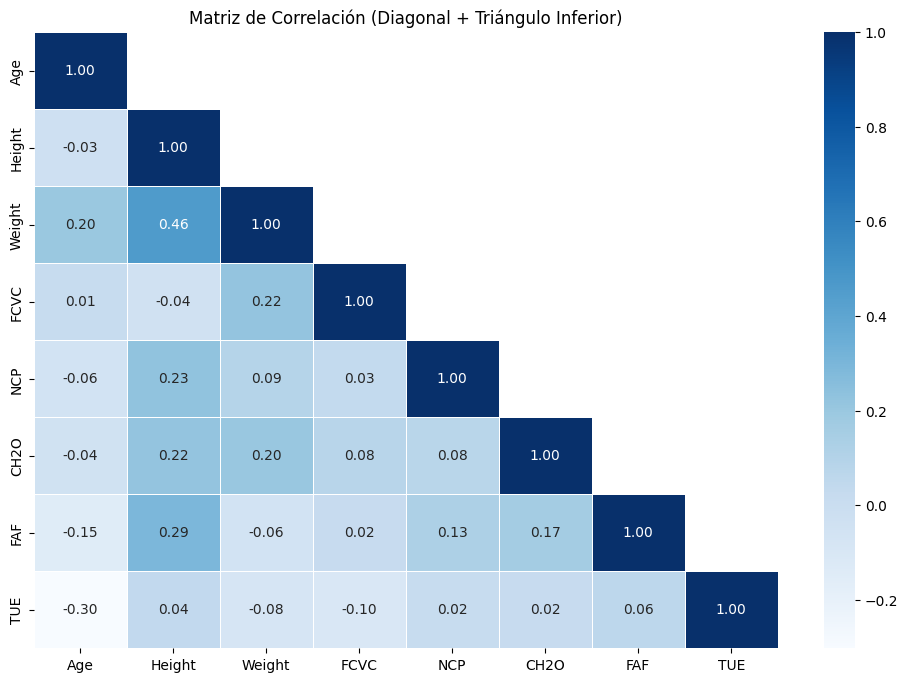

In [132]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1 deja visible la diagonal

plt.figure(figsize=(12,8))
sns.heatmap(corr, mask=mask, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación (Diagonal + Triángulo Inferior)")
plt.show()

## 4.2 Eliminar features correlacionadas > 0.85

In [133]:
threshold = 0.85

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            high_corr_pairs.append((col1, col2, corr.iloc[i, j]))

for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1} vs {col2} => Corr: {corr_val:.2f}")

## Eliminando FAF

In [134]:
# Se utiliza en caso de que  high_corr_pairs obtenga datos para eliminar de acuerdo al porcentaje especificado
#df = df.drop("columna_a_eliminar", axis=1)

# SECCIÓN 5 — Entrenamiento y comparación de solvers

## 5.1 Split

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 5.2 Función entrenar_modelo(solver, C)

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def entrenar_modelo(solver, C):
    modelo = LogisticRegression(
        solver=solver,
        C=C,
        max_iter=5000,
        multi_class="multinomial",
        n_jobs=-1
    )
    
    modelo.fit(X_train_final, y_train_final)
    y_pred = modelo.predict(X_test_final)
    
    acc = accuracy_score(y_test, y_pred)
    return acc

## 5.3 Comparación de solvers

In [137]:
solvers = ["lbfgs", "newton-cg", "sag", "saga"]
resultados = []

for s in solvers:
    acc = entrenar_modelo(solver=s, C=1)
    resultados.append((s, acc))

df_solvers = pd.DataFrame(resultados, columns=["Solver", "Accuracy"])
df_solvers

,Solver,Accuracy
0,lbfgs,0.894737
1,newton-cg,0.894737
2,sag,0.894737
3,saga,0.893142


### Grafico

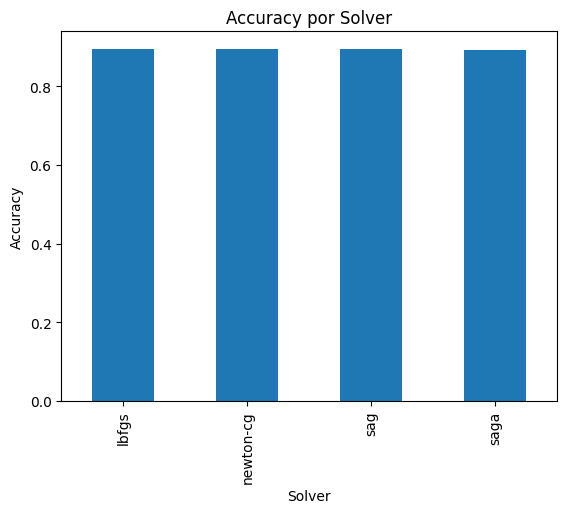

In [138]:
df_solvers.plot(x="Solver", y="Accuracy", kind="bar", legend=False)
plt.title("Accuracy por Solver")
plt.ylabel("Accuracy")
plt.show()

### Mejorar Solvers

In [139]:
mejor_solver = df_solvers.sort_values("Accuracy", ascending=False).iloc[0]["Solver"]
print("Mejor solver:", mejor_solver)

Mejor solver: lbfgs


## 5.4 Probar valores de C

In [140]:
valores_C = [0.01, 0.1, 1, 10]
resultados_C = []

for c in valores_C:
    acc = entrenar_modelo(solver=mejor_solver, C=c)
    resultados_C.append((c, acc))

df_C = pd.DataFrame(resultados_C, columns=["C", "Accuracy"])
df_C

,C,Accuracy
0,0.01,0.663477
1,0.10,0.791069
2,1.00,0.894737
3,10.00,0.944179


### Grafico

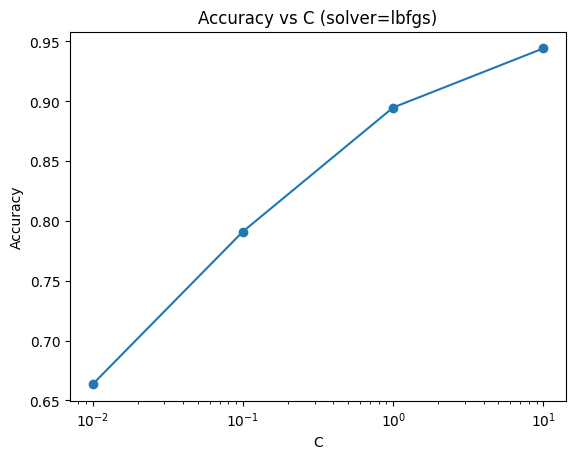

In [141]:
plt.plot(df_C["C"], df_C["Accuracy"], marker="o")
plt.xscale("log")
plt.title(f"Accuracy vs C (solver={mejor_solver})")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.show()

>El accuracy aumenta al incrementar C, indicando que el modelo mejora al reducir la regularización. Valores bajos de C generan underfitting, mientras que valores más altos permiten un mejor ajuste al patrón de los datos.

# SECCIÓN 6 — Evaluación e Interpretación del mejor modelo

In [142]:
mejor_C = df_C.sort_values("Accuracy", ascending=False).iloc[0]["C"]

modelo_final = LogisticRegression(
    solver=mejor_solver,
    C=mejor_C,
    max_iter=5000,
    multi_class="multinomial"
)

modelo_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_final.predict(X_test_final)

### Acurrancy Final

In [143]:
acc_final = accuracy_score(y_test, y_pred_final)
print(f"Accuracy final: {acc_final*100:.2f}%")

Accuracy final: 94.42%


### Matriz de Confusión

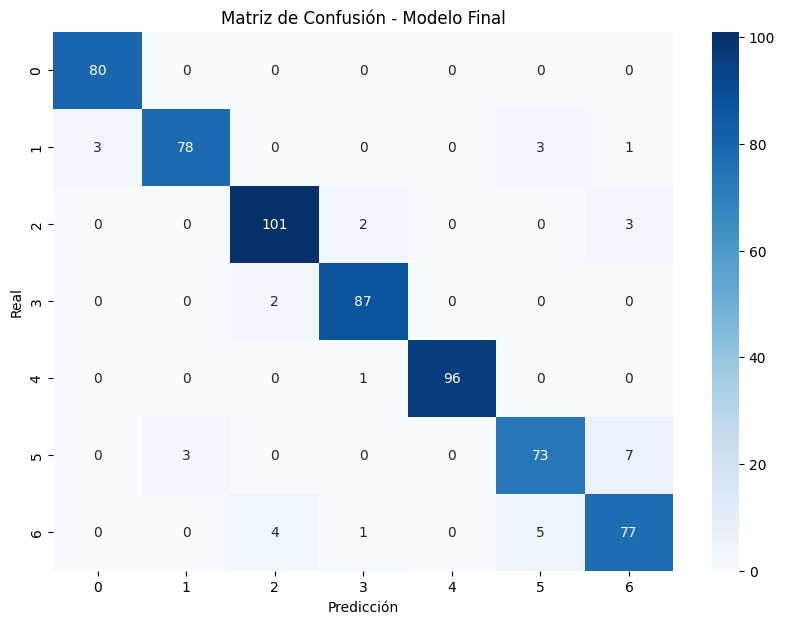

In [144]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Modelo Final")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### Reporte de clasificación

In [145]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        80
      Normal_Weight       0.96      0.92      0.94        85
     Obesity_Type_I       0.94      0.95      0.95       106
    Obesity_Type_II       0.96      0.98      0.97        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.90      0.88      0.89        83
Overweight_Level_II       0.88      0.89      0.88        87

           accuracy                           0.94       627
          macro avg       0.94      0.94      0.94       627
       weighted avg       0.94      0.94      0.94       627



### 6.2 Análisis del desempeño del modelo (Matriz de confusión y Classification Report)

<p style="text-align: justify">De acuerdo con el reporte de clasificación, el modelo presenta un desempeño general alto, alcanzando un accuracy aproximado del 94%. 
<p style="text-align: justify">Las clases con mejor desempeño son <b>Insufficient_Weight</b> y <b>Obesity_Type_III</b>, ya que presentan valores de precision y recall cercanos a 1.00. 
<p style="text-align: justify">Esto indica que el modelo es capaz de identificar correctamente estas clases y además realiza pocas predicciones incorrectas hacia ellas.

<p style="text-align: justify">Por otro lado, las clases <b>Overweight_Level_I</b> y <b>Overweight_Level_II</b> presentan los valores más bajos de precision y recall (alrededor de 0.87 - 0.90), lo que sugiere que son las clases más difíciles de predecir. Esto puede ocurrir porque estas categorías representan estados intermedios entre peso normal y obesidad, y comparten características similares con clases cercanas como <b>Normal_Weight</b> u <b>Obesity_Type_I</b>, lo que genera confusión en el modelo.

<p style="text-align: justify">La matriz de confusión permite confirmar esta situación, ya que los errores se concentran principalmente en categorías vecinas dentro de los niveles de sobrepeso y obesidad. 
<p style="text-align: justify">En general, el modelo mantiene un desempeño relativamente uniforme entre clases, aunque se observa que las clases de transición (sobrepeso) son más propensas a ser confundidas debido a su cercanía estadística con otras categorías.

<h3>6.3 Conclusiones finales</h3>

<p style="text-align: justify;">
En este proyecto se implementó un modelo de <b>Regresión Logística Multinomial</b> para predecir el nivel de obesidad (7 clases) utilizando el dataset <i>Obesity Levels</i>.
</p>

<p style="text-align: justify;">
El modelo final obtuvo un <b>accuracy aproximado de 94.42%</b>, lo cual indica un desempeño general alto y una buena capacidad de clasificación en el conjunto de prueba.
</p>

<p style="text-align: justify;">
Durante el desarrollo se realizaron decisiones importantes como la eliminación de duplicados, la codificación de variables categóricas mediante <b>OneHotEncoding</b> y el escalado de variables numéricas con <b>StandardScaler</b>, lo cual permitió mejorar la estabilidad del entrenamiento y la capacidad predictiva del modelo.
</p>

<p style="text-align: justify;">
Además, se evaluó el balance de clases y se determinó que el dataset estaba relativamente balanceado, por lo cual no fue necesario aplicar técnicas como <b>SMOTE</b>.
</p>

<p style="text-align: justify;">
Posteriormente, se compararon distintos <b>solvers</b> y valores del parámetro de regularización <b>C</b>, seleccionando aquellos que maximizaron el accuracy del modelo.
</p>

<p style="text-align: justify;">
Como limitaciones, la regresión logística es un modelo lineal y puede presentar dificultades al separar clases que tienen características muy similares, como ocurre en los niveles intermedios de sobrepeso.
</p>

<p style="text-align: justify;">
Como mejora futura, se podría explorar el uso de modelos más complejos como <b>Random Forest</b>, <b>Gradient Boosting</b> o redes neuronales, además de realizar selección de features más avanzada y validación cruzada para mejorar la generalización del modelo.
</p>